# ABC calibration
Aim of this notebook is to define the number of sample needed for each ABC calibration

In [38]:
from calibration.abc import RejectionABC
from pathlib import Path
from calibration.distance import REGISTRY as DISTANCE_REGISTRY

from calibration.runner import run_batch
from calibration.config_gen import generate
from calibration.target import load_target

TARGET = load_target({"data_dir":"/home/ben/projects/EvoSeerEngine/ISIC_2024"})

In [48]:
BASE_SEED = 42 
MAX_SAMPLES = 500

In [49]:
config = generate("../evoseer/config/erk_ois.yaml", params={})

pooled = run_batch(config, MAX_SAMPLES, BASE_SEED)

  run 1/500 — 2 clones
  run 2/500 — 2 clones
  run 3/500 — 2 clones
  run 4/500 — 2 clones
  run 5/500 — 2 clones
  run 6/500 — 2 clones
  run 7/500 — 2 clones
  run 8/500 — 2 clones
  run 9/500 — 2 clones
  run 10/500 — 2 clones
  run 11/500 — 2 clones
  run 12/500 — 2 clones
  run 13/500 — 3 clones
  run 14/500 — 5 clones
  run 15/500 — 4 clones
  run 16/500 — 3 clones
  run 17/500 — 2 clones
  run 18/500 — 3 clones
  run 19/500 — 2 clones
  run 20/500 — 2 clones
  run 21/500 — 2 clones
  run 22/500 — 2 clones
  run 23/500 — 2 clones
  run 24/500 — 2 clones
  run 25/500 — 2 clones
  run 26/500 — 2 clones
  run 27/500 — 2 clones
  run 28/500 — 2 clones
  run 29/500 — 2 clones
  run 30/500 — 2 clones
  run 31/500 — 2 clones
  run 32/500 — 2 clones
  run 33/500 — 2 clones
  run 34/500 — 2 clones
  run 35/500 — 3 clones
  run 36/500 — 3 clones
  run 37/500 — 3 clones
  run 38/500 — 2 clones
  run 39/500 — 3 clones
  run 40/500 — 2 clones
  run 41/500 — 2 clones
  run 42/500 — 3 clones
 

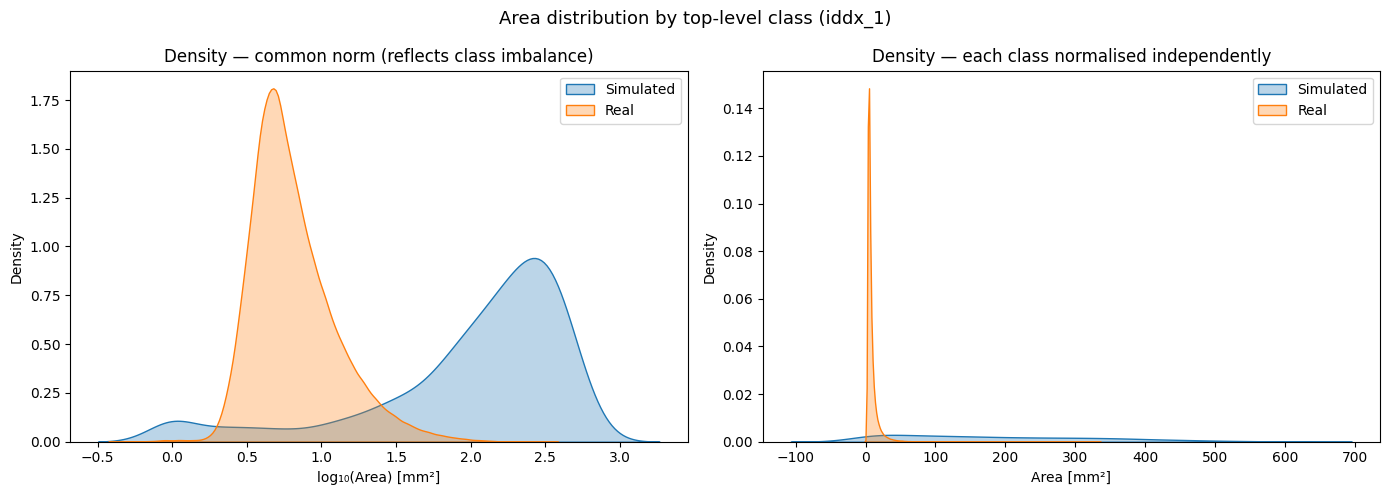

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.kdeplot(np.log10(pooled), ax=axes[0], label="Simulated", fill=True, alpha=0.3)
sns.kdeplot(np.log10(TARGET), ax=axes[0], label="Real", fill=True, alpha=0.3)

axes[0].set_xlabel("log₁₀(Area) [mm²]")
axes[0].set_title("Density — common norm (reflects class imbalance)")
axes[0].legend()

sns.kdeplot(pooled, ax=axes[1], label="Simulated", fill=True, alpha=0.3)
sns.kdeplot(TARGET, ax=axes[1], label="Real", fill=True, alpha=0.3)

axes[1].set_xlabel("Area [mm²]")
axes[1].set_title("Density — each class normalised independently")
axes[1].legend()

plt.suptitle("Area distribution by top-level class (iddx_1)", fontsize=13)
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

SMOOTH_WINDOW = 10
WINDOW = 10
THRESHOLDS = [0.01, 0.005, 0.0001]
COLORS = ['#90EE90', '#32CD32', '#228B22']  # light green → dark green

dist_series = {}
plateau_results = {}  # {distance_name: {threshold: plateau_n}}

# Precompute distance series once
for name, distance_cls in DISTANCE_REGISTRY.items():
    ns = list(range(1, MAX_SAMPLES))
    dist_values = [distance_cls().compute(pooled[:n], TARGET[:n]) for n in ns]
    smooth = np.convolve(dist_values, np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW, mode='valid')
    smooth_ns = ns[SMOOTH_WINDOW - 1:]
    dist_series[name] = (ns, dist_values, smooth, smooth_ns)
    plateau_results[name] = {}

# Compute plateau for each threshold
for threshold, color in zip(THRESHOLDS, COLORS):
    for name, (ns, dist_values, smooth, smooth_ns) in dist_series.items():
        plateau_n = smooth_ns[-1]  # default: last n
        try:
            for i in range(WINDOW, len(smooth)):
                rel_improvement = (smooth[i - WINDOW] - smooth[i]) / (smooth[i - WINDOW] + 1e-12)
                if 0 <= rel_improvement < threshold:
                    plateau_n = smooth_ns[i]
                    break
        except (IndexError, ValueError) as e:
            print(f"Warning: {name} threshold={threshold} → {e}")
        
        plateau_results[name][threshold] = plateau_n

# Summary table
table_data = []
for name in sorted(plateau_results.keys()):
    row = {'Method': name}
    for threshold in THRESHOLDS:
        row[f'n (threshold={threshold})'] = plateau_results[name].get(threshold, 'N/A')
    table_data.append(row)

df = pd.DataFrame(table_data)
print(df.to_string(index=False))


     Method  n (threshold=0.01)  n (threshold=0.005)  n (threshold=0.0001)
         ks                  26                   54                   190
         l1                 121                  122                   489
         l2                  50                   50                   331
wasserstein                 121                  122                   489


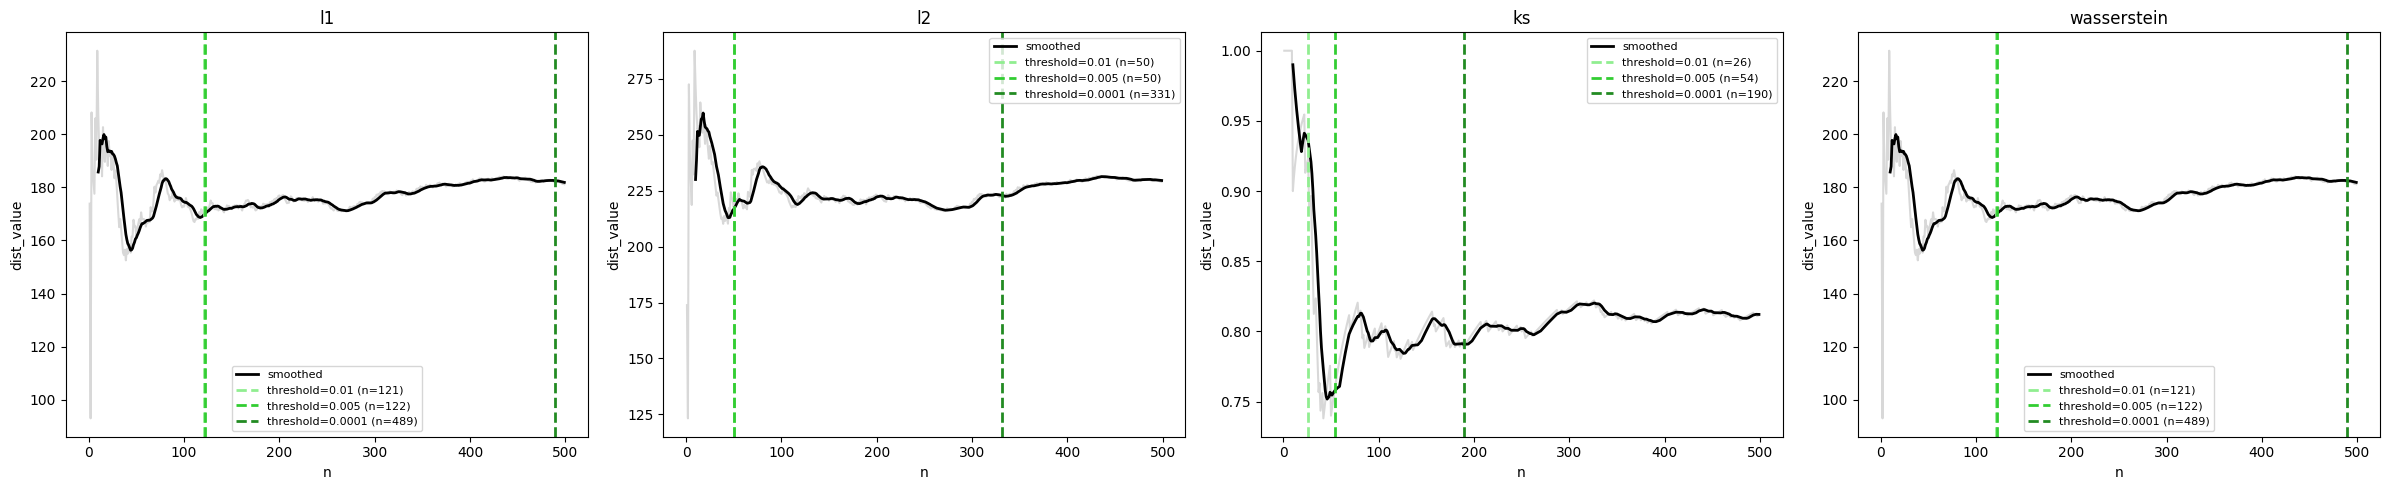

In [58]:
fig, axes = plt.subplots(1, len(DISTANCE_REGISTRY), figsize=(6 * len(DISTANCE_REGISTRY), 5))
if len(DISTANCE_REGISTRY) == 1:
    axes = [axes]

for ax, name in zip(axes, DISTANCE_REGISTRY):
    ns, dist_values, smooth, smooth_ns = dist_series[name]
    
    ax.plot(ns, dist_values, alpha=0.3, color='gray')
    ax.plot(smooth_ns, smooth, linewidth=2, color='black', label='smoothed')
    
    for threshold, color in zip(THRESHOLDS, COLORS):
        plateau_n = plateau_results[name][threshold]
        ax.axvline(plateau_n, color=color, linestyle='--', linewidth=2, label=f'threshold={threshold} (n={plateau_n})')
    
    ax.set_xlabel('n')
    ax.set_ylabel('dist_value')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
